In [ ]:
import pandas as pd

df = pd.read_csv("train_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print(df.shape)

(614, 13)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [1]:
df.describe()

NameError: name 'df' is not defined

In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History'].fillna(df['Credit_History'].mode()[0])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

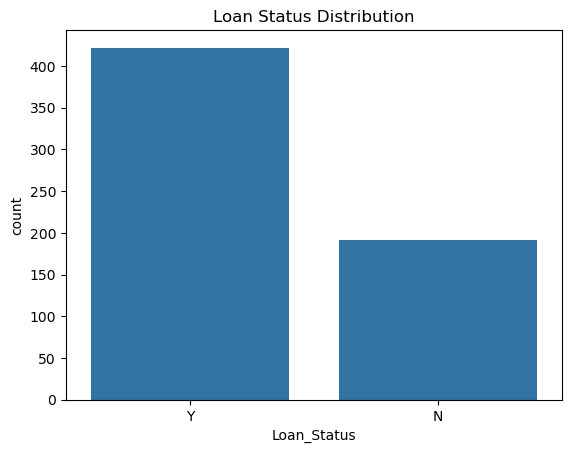

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")

plt.savefig("images/loan_status.png")

plt.show()

# Credit History


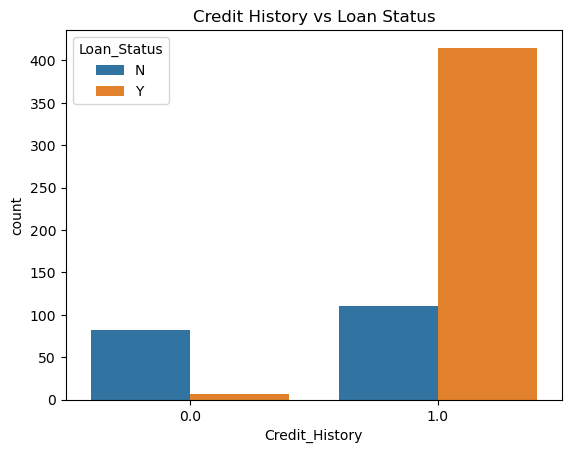

In [12]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.savefig("images/credit_history.png")
plt.show()

# Income Distribution

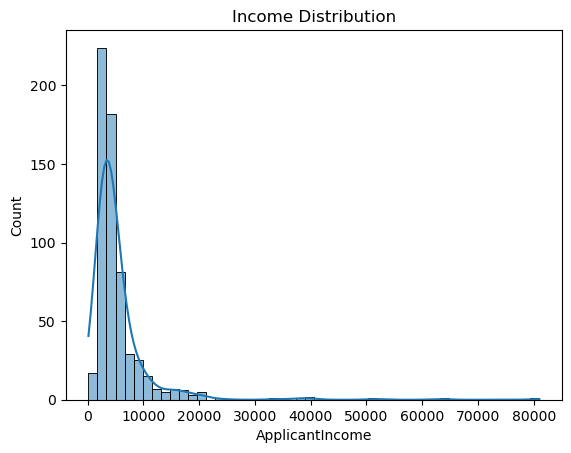

In [13]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Income Distribution")
plt.savefig("images/income.png")
plt.show()

# Loan Amount Distribution

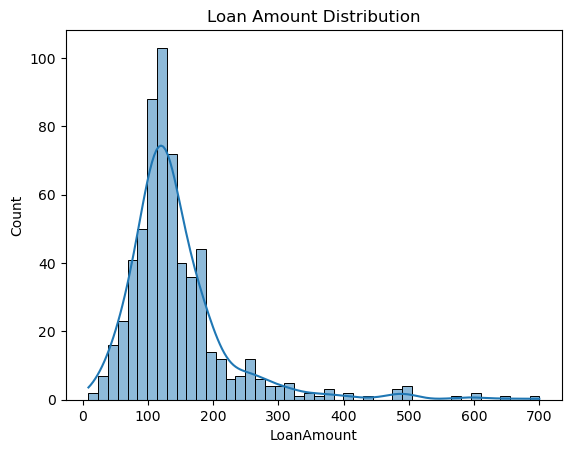

In [14]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.savefig("images/loan_amount.png")
plt.show()

# Outlier Detection

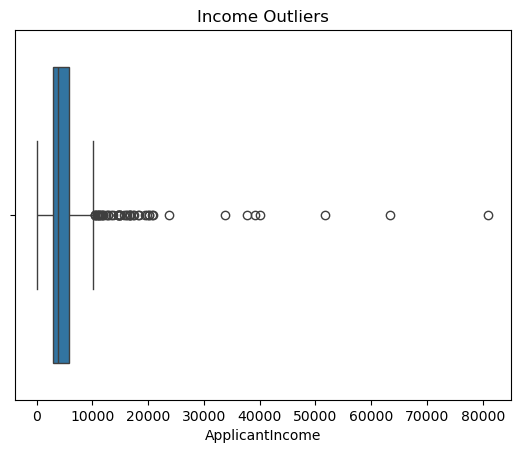

In [15]:
sns.boxplot(x=df['ApplicantIncome'])
plt.title("Income Outliers")
plt.savefig("images/outliers.png")
plt.show()

# Gender vs Loan approval

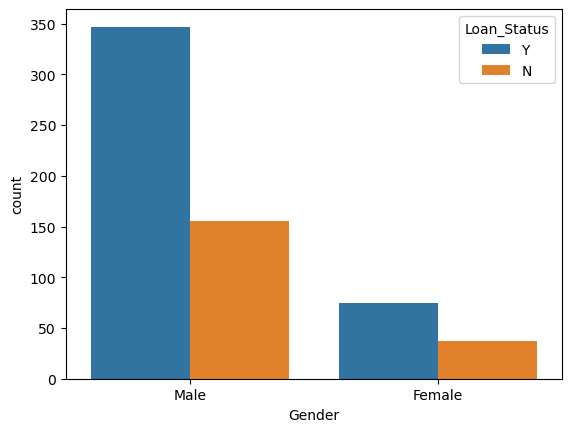

In [16]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.savefig("images/gender.png")
plt.show()

# Education vs Loan

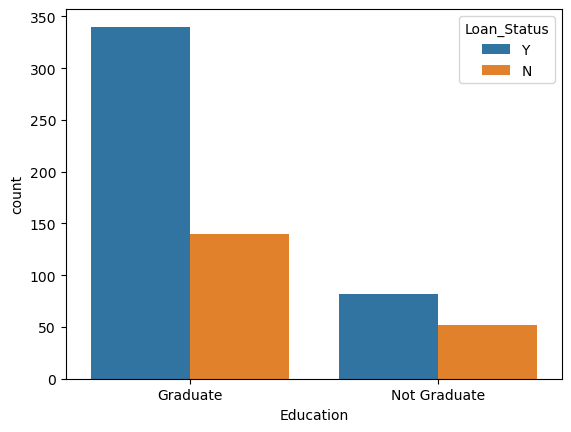

In [17]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.savefig("images/education.png")
plt.show()

# Property Area Analysis

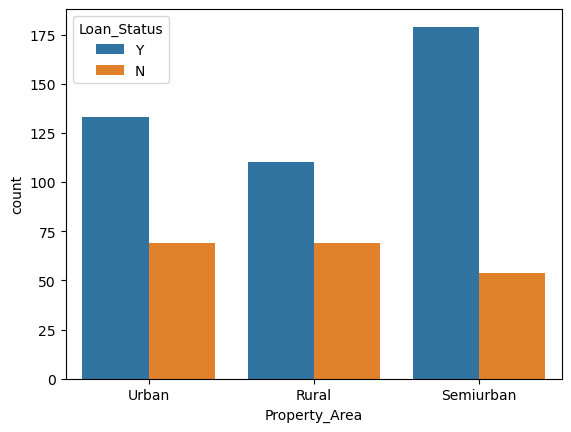

In [18]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.savefig("images/property.png")
plt.show()

# Income vs Loan

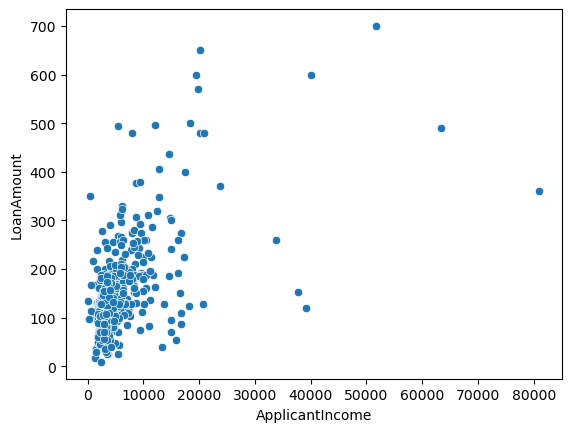

In [19]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.savefig("images/scatter.png")
plt.show()

# Heatmap (Feature Relationships)

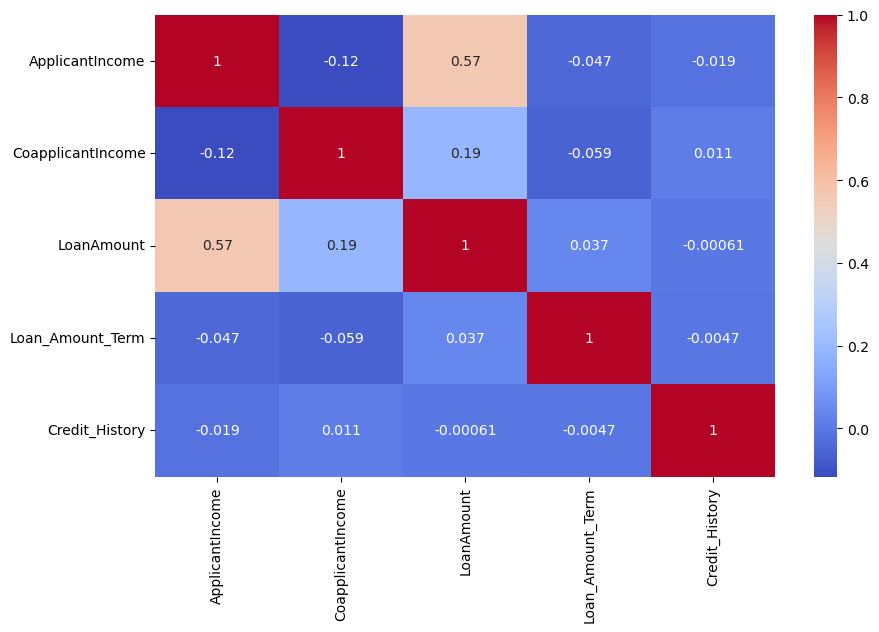

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.savefig("images/heatmap.png")
plt.show()

# Pair plot

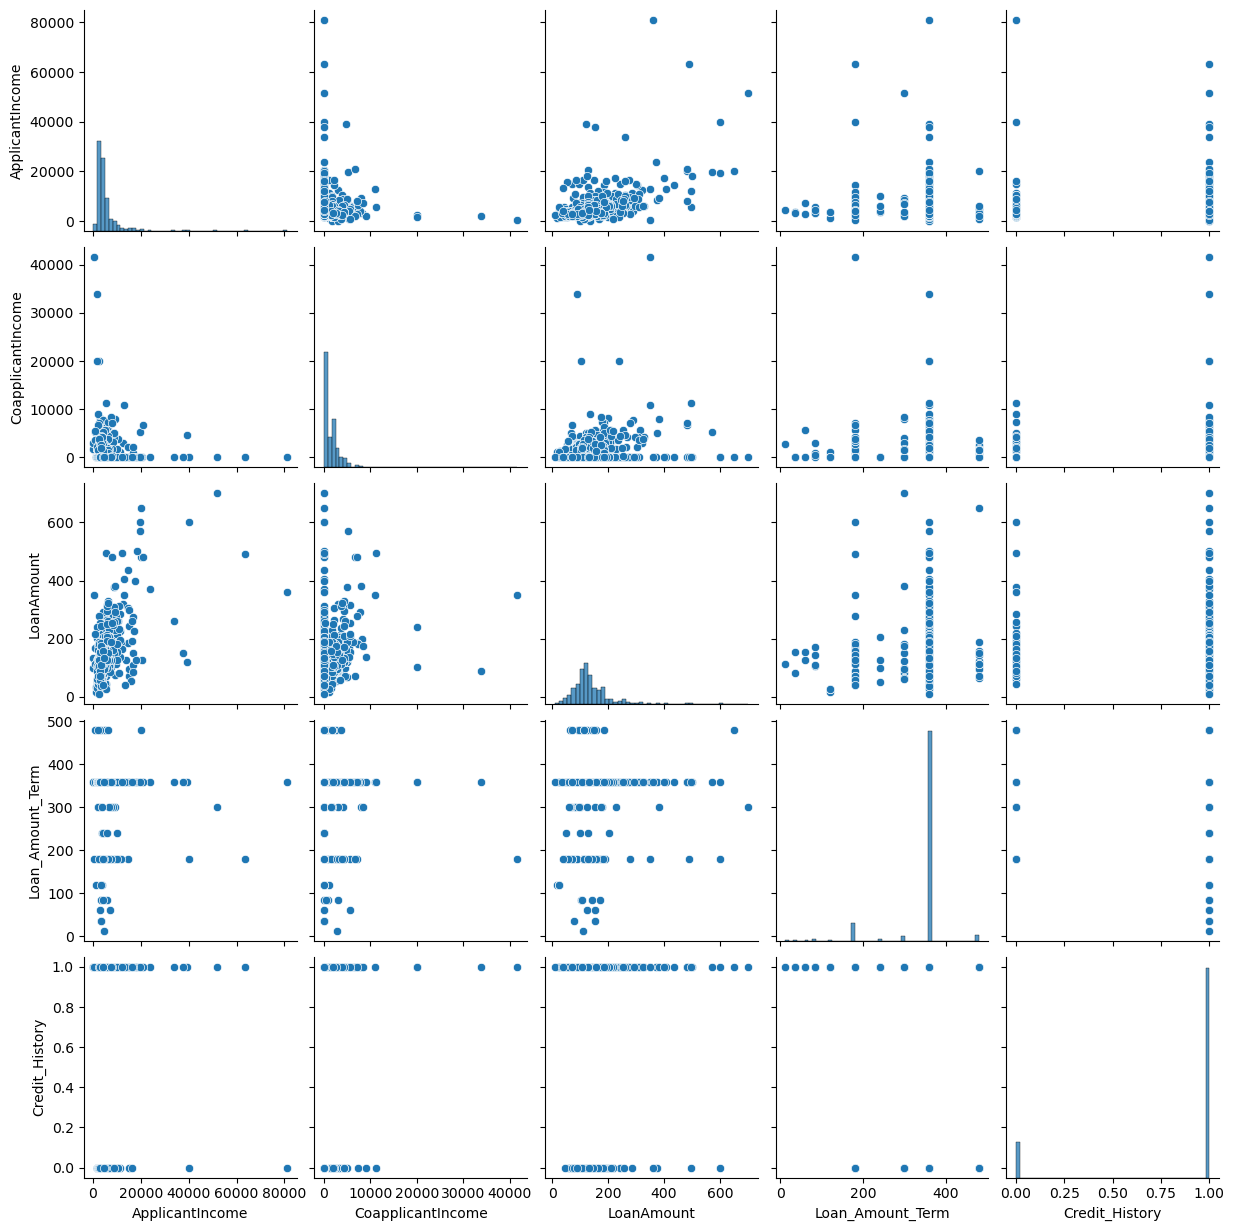

In [21]:
sns.pairplot(df)
plt.savefig("images/pairplot.png")
plt.show()

# Violin Plot

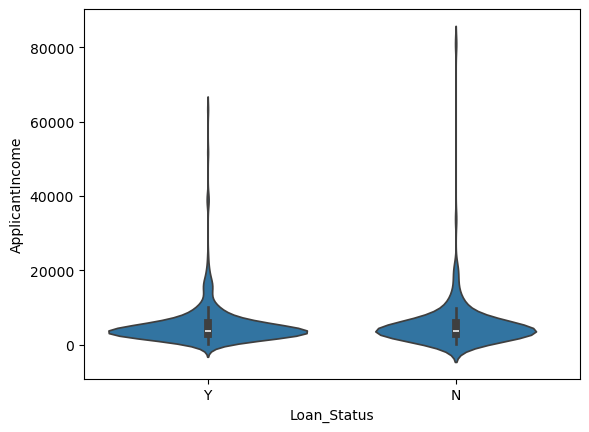

In [22]:
sns.violinplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.savefig("images/violin.png")
plt.show()

# Model training and prediction

In [24]:
df.replace({
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0}
})

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,1,1,3+,1,0,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,Urban,1


In [25]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [26]:
df['Property_Area'] = df['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

# Features

In [27]:
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# train- test 

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic regression

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

D:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



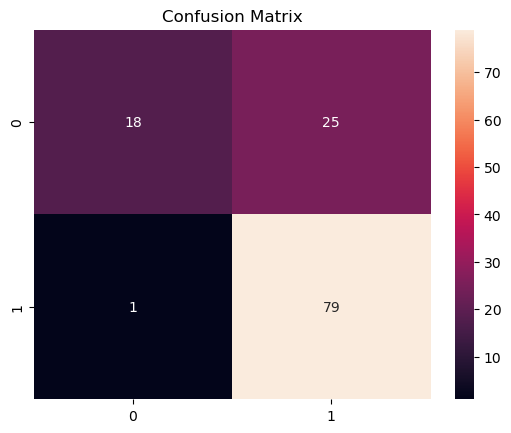

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("images/confusion_matrix.png")
plt.show()

# Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7723577235772358


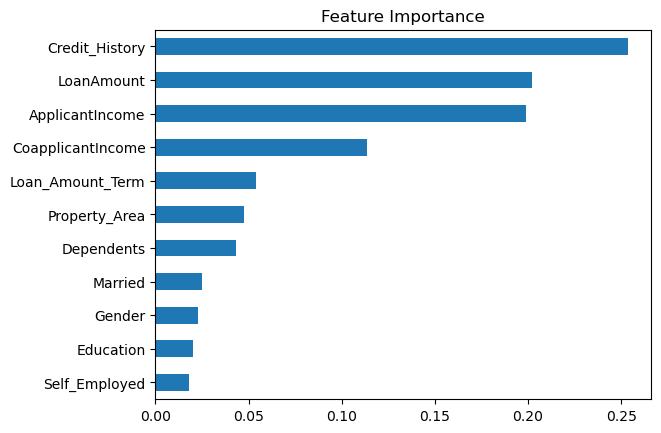

In [34]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.savefig("images/feature_importance.png")
plt.show()

In [35]:
def predict_loan(data):
    prediction = rf.predict([data])
    
    if prediction[0] == 1:
        return "Loan Approved ✅"
    else:
        return "Loan Rejected ❌"

In [40]:
sample_data = [1, 1, 2, 0, 1, 2000, 0, 200, 360, 0, 0]

print(predict_loan(sample_data))

Loan Rejected ❌


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [41]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
